## 1. Imports and Setup

In [ ]:
!pip install opencv-python-headless -q

In [ ]:
import os
import gc
import warnings
import random
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', len(gpus) > 0)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

IMG_SIZE       = (224, 224)
FRAMES_PER_VID = 16
FEATURE_DIM    = 1280
BATCH_SIZE     = 16
CLASS_NAMES    = ['Normal', 'Shoplifting']

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
print('Setup complete.')

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

TensorFlow: 2.19.0
Keras: 3.13.2


## 2. Mount Drive and Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to match your Drive folder
DATASET_PATH    = '/content/drive/MyDrive/ML 2026/Video Model/shoplifting dataset'
NORMAL_DIR      = os.path.join(DATASET_PATH, 'normal')
SHOPLIFTING_DIR = os.path.join(DATASET_PATH, 'shoplifting')
FRAMES_DIR      = '/content/frames'

os.makedirs(FRAMES_DIR, exist_ok=True)

for name, path in [('Normal', NORMAL_DIR), ('Shoplifting', SHOPLIFTING_DIR)]:
    exists = os.path.exists(path)
    count  = len([f for f in os.listdir(path) if f.endswith('.mp4')]) if exists else 0
    print(f'{name}: {count} videos found')

Mounted at /content/drive
Normal: 90 videos found
Shoplifting: 92 videos found


In [ ]:
records = []
for label, folder, cls in [
    (0, NORMAL_DIR,      'Normal'),
    (1, SHOPLIFTING_DIR, 'Shoplifting')
]:
    for fname in sorted(os.listdir(folder)):
        if fname.endswith('.mp4'):
            records.append({
                'path':  os.path.join(folder, fname),
                'label': label,
                'class': cls,
                'fname': fname
            })

df = pd.DataFrame(records).sample(frac=1, random_state=SEED).reset_index(drop=True)
print('Total videos  :', len(df))
print('Normal        :', (df.label == 0).sum())
print('Shoplifting   :', (df.label == 1).sum())
df.head()

Total videos  : 182
Normal        : 90
Shoplifting   : 92


,path,label,class,fname
0,/content/drive/MyDrive/ML 2026/Video Model/sho...,0,Normal,normal-27.mp4
1,/content/drive/MyDrive/ML 2026/Video Model/sho...,0,Normal,normal-48.mp4
2,/content/drive/MyDrive/ML 2026/Video Model/sho...,1,Shoplifting,shoplifting-69.mp4
3,/content/drive/MyDrive/ML 2026/Video Model/sho...,1,Shoplifting,shoplifting-17.mp4
4,/content/drive/MyDrive/ML 2026/Video Model/sho...,1,Shoplifting,shoplifting-61.mp4


## 3. Exploratory Data Analysis

In [ ]:
# Check video properties
print('Video Properties Sample:')
durations = []
for _, row in df.head(8).iterrows():
    cap    = cv2.VideoCapture(row['path'])
    fps    = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    dur    = frames / fps if fps > 0 else 0
    durations.append(dur)
    cap.release()
    print(f'  {row["fname"]:<28} {w}x{h}  {fps:.0f}fps  {frames} frames  {dur:.1f}s  {row["class"]}')
print(f'Average duration: {np.mean(durations):.1f}s')

Video Properties Sample:
  normal-27.mp4                640x480  30fps  321 frames  10.7s  Normal
  normal-48.mp4                640x480  30fps  320 frames  10.7s  Normal
  shoplifting-69.mp4           640x480  30fps  325 frames  10.8s  Shoplifting
  shoplifting-17.mp4           640x480  30fps  321 frames  10.7s  Shoplifting
  shoplifting-61.mp4           640x480  30fps  308 frames  10.3s  Shoplifting
  normal-23.mp4                640x480  30fps  318 frames  10.6s  Normal
  normal-31.mp4                640x480  30fps  361 frames  12.0s  Normal
  normal-71.mp4                640x480  30fps  341 frames  11.4s  Normal
Average duration: 10.9s


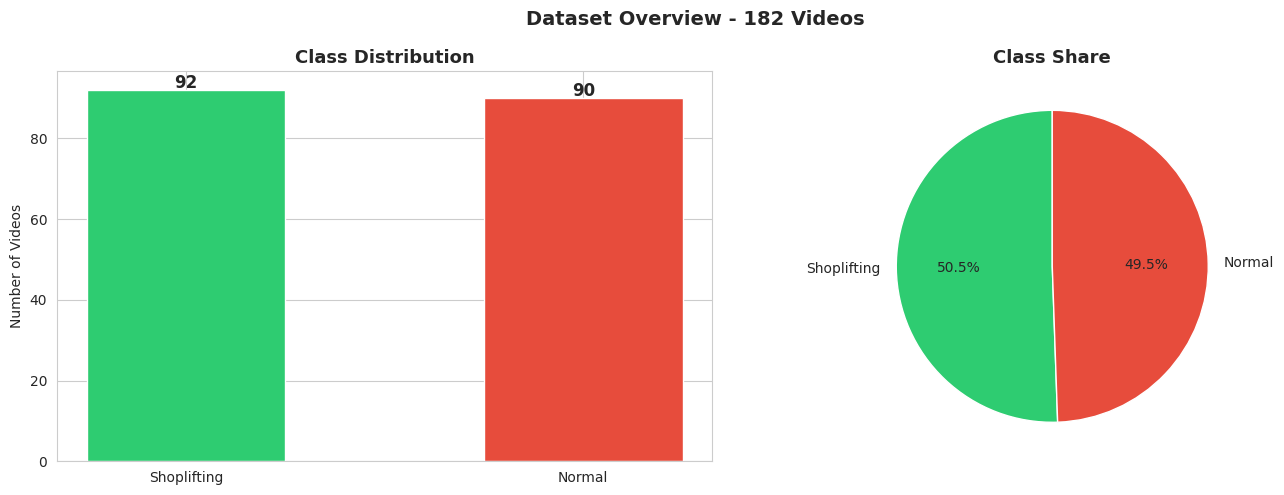

In [ ]:
# Class distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['class'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Videos')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 0.5, str(cnt), ha='center', fontsize=12, fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
             colors=colors, startangle=90)
axes[1].set_title('Class Share', fontsize=13, fontweight='bold')
plt.suptitle('Dataset Overview - 182 Videos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

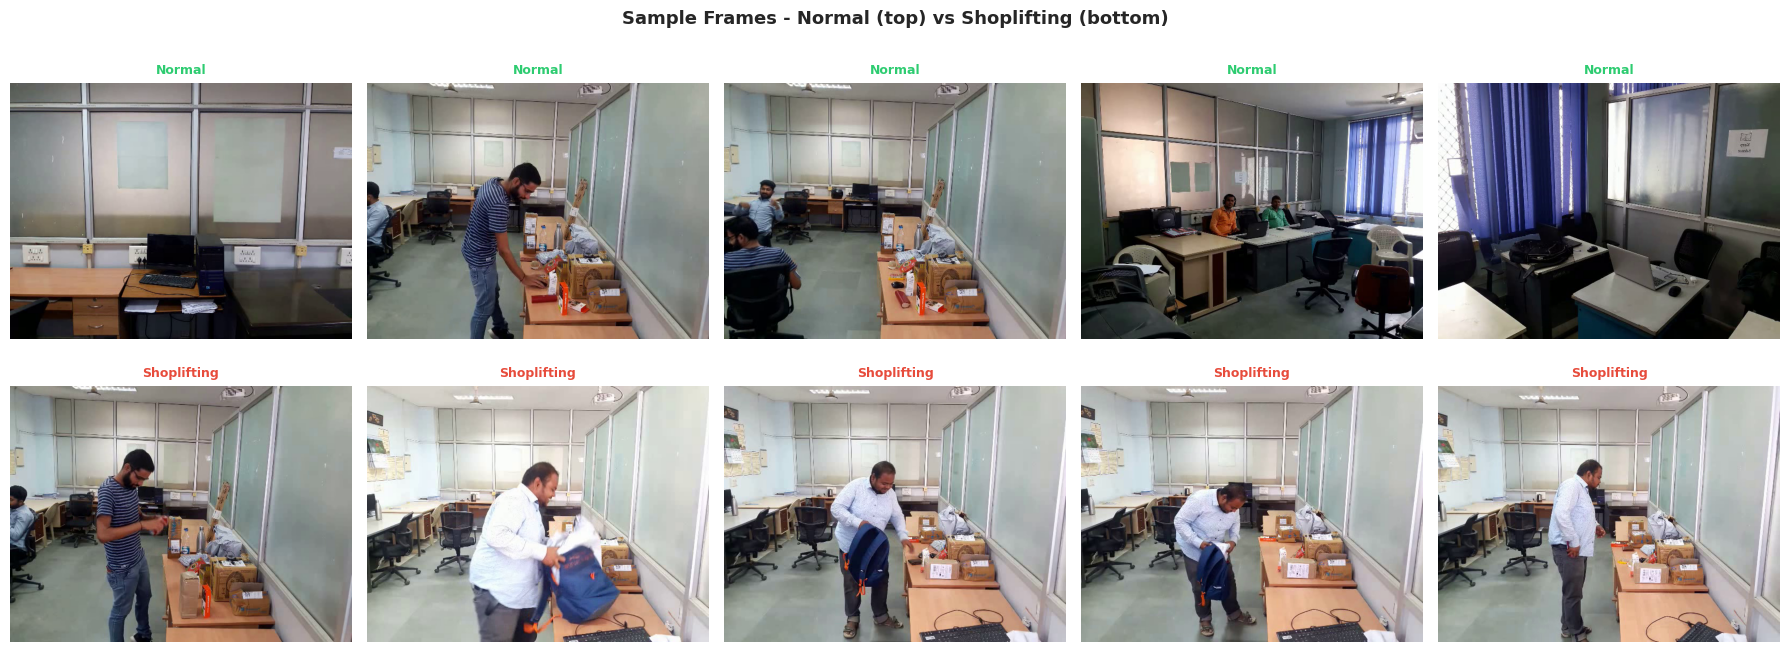

In [ ]:
# Sample frames from both classes
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row_i, (cls, folder) in enumerate([('Normal', NORMAL_DIR), ('Shoplifting', SHOPLIFTING_DIR)]):
    videos = sorted([f for f in os.listdir(folder) if f.endswith('.mp4')])[:5]
    for col_i, fname in enumerate(videos):
        cap   = cv2.VideoCapture(os.path.join(folder, fname))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
        ret, frame = cap.read()
        cap.release()
        if ret:
            axes[row_i][col_i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        color = '#e74c3c' if cls == 'Shoplifting' else '#2ecc71'
        axes[row_i][col_i].set_title(cls, fontsize=9, color=color, fontweight='bold')
        axes[row_i][col_i].axis('off')
plt.suptitle('Sample Frames - Normal (top) vs Shoplifting (bottom)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Frame Extraction

In [ ]:
def extract_frames(video_path, n_frames=16):
    """
    Extract n evenly-spaced frames from a video.
    Returns list of RGB frames resized to IMG_SIZE.
    """
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)

    if total <= 0:
        cap.release()
        return [], 0, 0

    indices = set(np.linspace(0, total - 1, n_frames, dtype=int))
    frames, fi = [], 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if fi in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, IMG_SIZE)
            frames.append(frame)
        fi += 1
    cap.release()

    if len(frames) < n_frames:
        pad    = [np.zeros((*IMG_SIZE, 3), dtype=np.uint8)] * (n_frames - len(frames))
        frames = frames + pad

    return frames[:n_frames], fps, total


print(f'Extracting {FRAMES_PER_VID} frames per video from {len(df)} videos...')
failed = []

for i, row in df.iterrows():
    out_dir = os.path.join(FRAMES_DIR, row['class'], row['fname'].replace('.mp4', ''))
    os.makedirs(out_dir, exist_ok=True)

    if len(os.listdir(out_dir)) >= FRAMES_PER_VID:
        continue

    frames, _, _ = extract_frames(row['path'], FRAMES_PER_VID)
    if not frames:
        failed.append(row['fname'])
        continue

    for j, f in enumerate(frames):
        cv2.imwrite(
            os.path.join(out_dir, f'frame_{j:02d}.jpg'),
            cv2.cvtColor(f, cv2.COLOR_RGB2BGR)
        )

    if (i + 1) % 30 == 0:
        print(f'  [{i+1}/{len(df)}] processed')

print(f'Extraction done. Failed: {len(failed)}')
for cls in CLASS_NAMES:
    n = sum(len(files) for _, _, files in os.walk(os.path.join(FRAMES_DIR, cls)))
    print(f'  {cls}: {n} frames')

Extracting 16 frames per video from 182 videos...
  [30/182] processed
  [60/182] processed
  [90/182] processed
  [120/182] processed
  [150/182] processed
  [180/182] processed
Extraction done. Failed: 0
  Normal: 1440 frames
  Shoplifting: 1472 frames


---
## MODEL A - CNN Only (Spatial Classification)

**Approach:** Each video frame is treated as an independent image.  
**Architecture:** MobileNetV2 (pretrained on ImageNet) + Dense classification head.  

## 5a. Prepare Image Dataset for CNN

In [ ]:
FLAT_CNN = '/content/flat_cnn'

def flatten_frames(src_dir, dst_dir):
    """Flatten class/video_id/frame.jpg to class/video_frame.jpg for Keras generators."""
    os.makedirs(dst_dir, exist_ok=True)
    for cls in CLASS_NAMES:
        cls_src = os.path.join(src_dir, cls)
        cls_dst = os.path.join(dst_dir, cls)
        os.makedirs(cls_dst, exist_ok=True)
        if not os.path.exists(cls_src):
            continue
        for vid in os.listdir(cls_src):
            vid_dir = os.path.join(cls_src, vid)
            for frame in os.listdir(vid_dir):
                src = os.path.join(vid_dir, frame)
                dst = os.path.join(cls_dst, f'{vid}_{frame}')
                if not os.path.exists(dst):
                    shutil.copy2(src, dst)

flatten_frames(FRAMES_DIR, FLAT_CNN)

for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(FLAT_CNN, cls)))
    print(f'{cls}: {n} frames')

Normal: 1440 frames
Shoplifting: 1472 frames


In [ ]:
# Split frames into train / val / test
FLAT_CNN_SPLIT = '/content/flat_cnn_split'

for cls in CLASS_NAMES:
    all_frames = os.listdir(os.path.join(FLAT_CNN, cls))
    random.shuffle(all_frames)
    n       = len(all_frames)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)
    splits  = {
        'train': all_frames[:n_train],
        'val':   all_frames[n_train:n_train + n_val],
        'test':  all_frames[n_train + n_val:]
    }
    for split, flist in splits.items():
        dst = os.path.join(FLAT_CNN_SPLIT, split, cls)
        os.makedirs(dst, exist_ok=True)
        for fname in flist:
            src = os.path.join(FLAT_CNN, cls, fname)
            if not os.path.exists(os.path.join(dst, fname)):
                shutil.copy2(src, os.path.join(dst, fname))

print('Split complete:')
for split in ['train', 'val', 'test']:
    total = sum(len(os.listdir(os.path.join(FLAT_CNN_SPLIT, split, c))) for c in CLASS_NAMES)
    print(f'  {split}: {total} frames')

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

cnn_train_gen = train_datagen.flow_from_directory(
    os.path.join(FLAT_CNN_SPLIT, 'train'),
    target_size=IMG_SIZE, batch_size=32,
    class_mode='binary', shuffle=True, seed=SEED
)
cnn_val_gen = val_test_datagen.flow_from_directory(
    os.path.join(FLAT_CNN_SPLIT, 'val'),
    target_size=IMG_SIZE, batch_size=32,
    class_mode='binary', shuffle=False
)
cnn_test_gen = val_test_datagen.flow_from_directory(
    os.path.join(FLAT_CNN_SPLIT, 'test'),
    target_size=IMG_SIZE, batch_size=32,
    class_mode='binary', shuffle=False
)
print('Class indices:', cnn_train_gen.class_indices)

Split complete:
  train: 2037 frames
  val: 436 frames
  test: 439 frames
Found 2037 images belonging to 2 classes.
Found 436 images belonging to 2 classes.
Found 439 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Shoplifting': 1}


## 5b. Build CNN Model

In [ ]:
def build_cnn_model():
    """
    MobileNetV2 base (pretrained ImageNet) + custom dense head.
    Binary output: Normal vs Shoplifting.
    No temporal component - purely spatial classification.
    """
    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name='CNN_Only'), base


cnn_model, cnn_base = build_cnn_model()
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print('CNN Model summary:')
cnn_model.summary()
print(f'Total params: {cnn_model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN Model summary:


Model: "CNN_Only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,050,561 (11.64 MB)

 Trainable params: 790,017 (3.01 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Total params: 3,050,561


## 5c. Train CNN — Phase 1 (Frozen Base) + Phase 2 (Fine-tuning)

In [ ]:
# Phase 1 - train only the classification head
print('--- CNN Phase 1: Training classification head (base frozen) ---')

cnn_callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('cnn_best_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

cnn_history1 = cnn_model.fit(
    cnn_train_gen,
    epochs=20,
    validation_data=cnn_val_gen,
    callbacks=cnn_callbacks_p1,
    verbose=1
)
cnn_p1_best = max(cnn_history1.history['val_accuracy'])
print(f'Phase 1 best val accuracy: {cnn_p1_best:.4f}')

--- CNN Phase 1: Training classification head (base frozen) ---
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.6202 - loss: 0.7859
Epoch 1: val_accuracy improved from None to 0.60092, saving model to cnn_best_phase1.keras

Epoch 1: finished saving model to cnn_best_phase1.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 963ms/step - accuracy: 0.6922 - loss: 0.6716 - val_accuracy: 0.6009 - val_loss: 0.6714 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.7739 - loss: 0.4893
Epoch 2: val_accuracy improved from 0.60092 to 0.79358, saving model to cnn_best_phase1.keras

Epoch 2: finished saving model to cnn_best_phase1.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 572ms/step - accuracy: 0.7732 - loss: 0.5012 - val_accuracy: 0.7936 - val_loss: 0.4404 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8152 - loss: 0.4338
Epoch 3: val_accuracy improved from 0.79358 to 0.82798, saving model to cnn_best_phase1.keras



In [ ]:
# Phase 2 - unfreeze top 30 layers for fine-tuning
print('--- CNN Phase 2: Fine-tuning top 30 layers ---')

cnn_base.trainable = True
for layer in cnn_base.layers[:-30]:
    layer.trainable = False

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('cnn_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

cnn_history2 = cnn_model.fit(
    cnn_train_gen,
    epochs=20,
    validation_data=cnn_val_gen,
    callbacks=cnn_callbacks_p2,
    verbose=1
)
cnn_p2_best = max(cnn_history2.history['val_accuracy'])
print(f'Phase 2 best val accuracy: {cnn_p2_best:.4f}')
print(f'Improvement over Phase 1 : +{(cnn_p2_best - cnn_p1_best)*100:.2f}%')

--- CNN Phase 2: Fine-tuning top 30 layers ---
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7657 - loss: 0.4642
Epoch 1: val_accuracy improved from None to 0.84862, saving model to cnn_best.keras

Epoch 1: finished saving model to cnn_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 730ms/step - accuracy: 0.7820 - loss: 0.4556 - val_accuracy: 0.8486 - val_loss: 0.3524 - learning_rate: 1.0000e-05
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.7990 - loss: 0.4191
Epoch 2: val_accuracy did not improve from 0.84862
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 454ms/step - accuracy: 0.8081 - loss: 0.4024 - val_accuracy: 0.8073 - val_loss: 0.4022 - learning_rate: 1.0000e-05
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8327 - loss: 0.3871
Epoch 3: val_accuracy did not improve from 0.84862
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 456ms/step - accuracy: 0.8282 - loss: 0.3920 - val_accuracy: 0.7821 - val_loss: 0.4450 - learning_rate: 1.0000e-05
Epoch 4/20
64/64 ━━━━

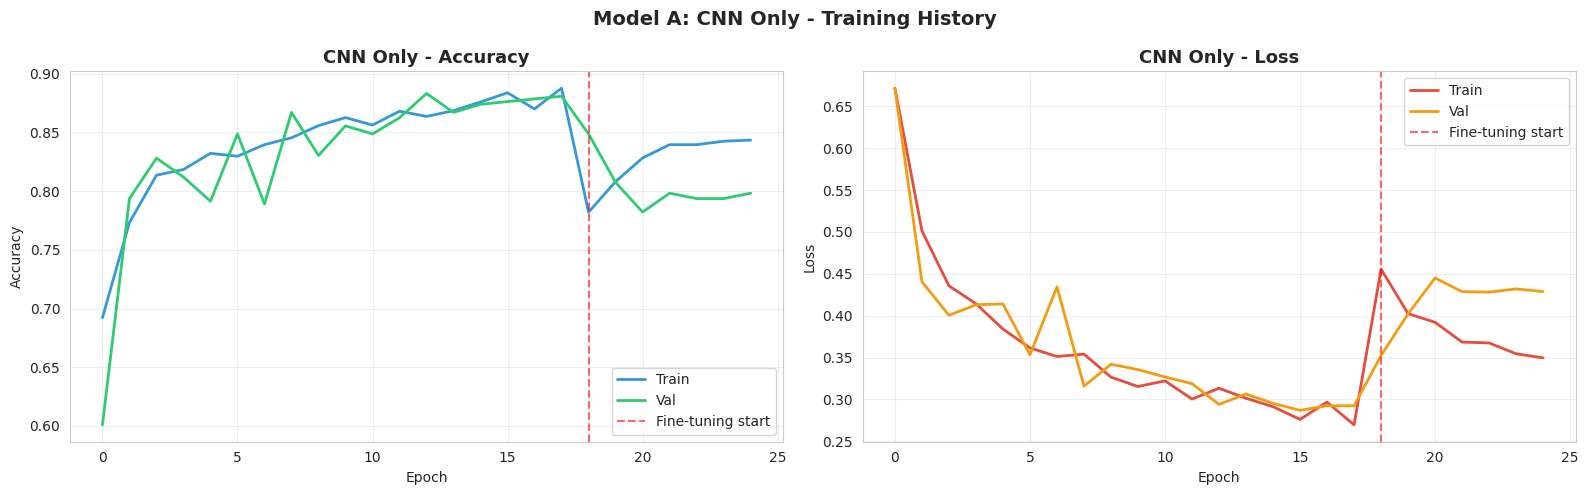

In [ ]:
# Plot CNN training history
cnn_acc  = cnn_history1.history['accuracy']     + cnn_history2.history['accuracy']
cnn_val  = cnn_history1.history['val_accuracy'] + cnn_history2.history['val_accuracy']
cnn_loss = cnn_history1.history['loss']         + cnn_history2.history['loss']
cnn_vloss= cnn_history1.history['val_loss']     + cnn_history2.history['val_loss']
p1_len   = len(cnn_history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(cnn_acc,  label='Train', color='#3498db', lw=2)
axes[0].plot(cnn_val,  label='Val',   color='#2ecc71', lw=2)
axes[0].axvline(p1_len, color='red', ls='--', alpha=0.6, label='Fine-tuning start')
axes[0].set_title('CNN Only - Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(cnn_loss,  label='Train', color='#e74c3c', lw=2)
axes[1].plot(cnn_vloss, label='Val',   color='#f39c12', lw=2)
axes[1].axvline(p1_len, color='red', ls='--', alpha=0.6, label='Fine-tuning start')
axes[1].set_title('CNN Only - Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Model A: CNN Only - Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5d. Evaluate CNN on Test Set

In [ ]:
cnn_best_model = keras.models.load_model('cnn_best.keras')

cnn_test_loss, cnn_test_acc = cnn_best_model.evaluate(cnn_test_gen, verbose=1)
cnn_pred_proba = cnn_best_model.predict(cnn_test_gen, verbose=0).flatten()
cnn_pred       = (cnn_pred_proba > 0.5).astype(int)
cnn_true       = cnn_test_gen.classes

cnn_f1        = f1_score(cnn_true, cnn_pred)
cnn_precision = precision_score(cnn_true, cnn_pred)
cnn_recall    = recall_score(cnn_true, cnn_pred)
fpr_cnn, tpr_cnn, _ = roc_curve(cnn_true, cnn_pred_proba)
cnn_auc       = auc(fpr_cnn, tpr_cnn)

print('=== MODEL A: CNN Only - Test Results ===')
print(f'Accuracy  : {cnn_test_acc:.4f}')
print(f'F1 Score  : {cnn_f1:.4f}')
print(f'Precision : {cnn_precision:.4f}')
print(f'Recall    : {cnn_recall:.4f}')
print(f'ROC AUC   : {cnn_auc:.4f}')
print()
print(classification_report(cnn_true, cnn_pred, target_names=CLASS_NAMES))

14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 942ms/step - accuracy: 0.8519 - loss: 0.3660
=== MODEL A: CNN Only - Test Results ===
Accuracy  : 0.8519
F1 Score  : 0.8403
Precision : 0.9243
Recall    : 0.7703
ROC AUC   : 0.9309

              precision    recall  f1-score   support

      Normal       0.80      0.94      0.86       217
 Shoplifting       0.92      0.77      0.84       222

    accuracy                           0.85       439
   macro avg       0.86      0.85      0.85       439
weighted avg       0.86      0.85      0.85       439



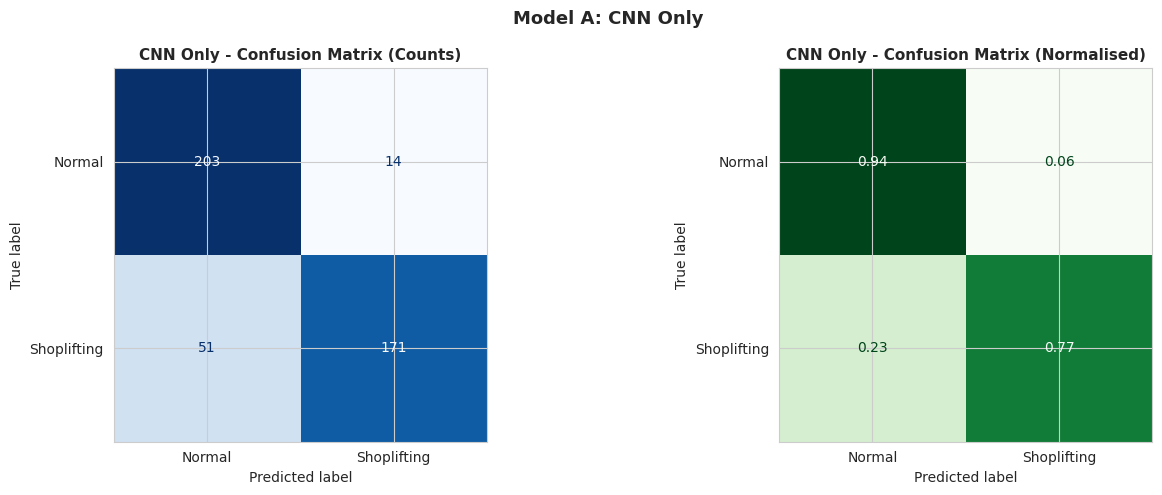

In [ ]:
# CNN confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_cnn = confusion_matrix(cnn_true, cnn_pred)

ConfusionMatrixDisplay(cm_cnn, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('CNN Only - Confusion Matrix (Counts)', fontsize=11, fontweight='bold')

cm_cnn_norm = cm_cnn.astype('float') / cm_cnn.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_cnn_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('CNN Only - Confusion Matrix (Normalised)', fontsize=11, fontweight='bold')

plt.suptitle('Model A: CNN Only', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## MODEL B - MobileNetV2 + LSTM (Spatial + Temporal)

**Approach:** Extract CNN features from a sequence of 16 frames per video.  
**Architecture:** MobileNetV2 feature extractor + Bidirectional LSTM.  

## 6a. Build CNN Feature Extractor

In [ ]:
base_fe = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_fe.trainable = False

feature_extractor = Model(
    inputs=base_fe.input,
    outputs=layers.GlobalAveragePooling2D()(base_fe.output),
    name='FeatureExtractor'
)

print(f'Feature extractor output shape: {feature_extractor.output_shape}')
print(f'Each video sequence shape: ({FRAMES_PER_VID}, {FEATURE_DIM})')

Feature extractor output shape: (None, 1280)
Each video sequence shape: (16, 1280)


## 6b. Extract CNN Features and Prepare Sequences

In [ ]:
def extract_video_features(video_path, extractor, n_frames=16):
    """Extract MobileNetV2 feature sequence from a video."""
    frames, _, _ = extract_frames(video_path, n_frames)
    if not frames:
        return None
    frames_arr = np.array(frames, dtype=np.float32)
    frames_pp  = preprocess_input(frames_arr)
    features   = extractor.predict(frames_pp, verbose=0)
    return features


print(f'Extracting features from {len(df)} videos...')
X_all, y_all = [], []
failed_fe    = []

for i, row in df.iterrows():
    feat = extract_video_features(row['path'], feature_extractor, FRAMES_PER_VID)
    if feat is not None:
        X_all.append(feat)
        y_all.append(row['label'])
    else:
        failed_fe.append(row['fname'])

    if (i + 1) % 30 == 0:
        print(f'  [{i+1}/{len(df)}] processed')

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
print(f'Feature array shape: {X_all.shape}')
print(f'Labels shape       : {y_all.shape}')
print(f'Failed             : {len(failed_fe)}')
gc.collect()

Extracting features from 182 videos...
  [30/182] processed
  [60/182] processed
  [90/182] processed
  [120/182] processed
  [150/182] processed
  [180/182] processed
Feature array shape: (182, 16, 1280)
Labels shape       : (182,)
Failed             : 0


34907

In [ ]:
# Train / val / test split - stratified 70/15/15
X_tmp,  X_test,  y_tmp,  y_test  = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED)
X_train, X_val,  y_train, y_val  = train_test_split(
    X_tmp, y_tmp, test_size=0.176, stratify=y_tmp, random_state=SEED)
del X_tmp, y_tmp
gc.collect()

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

# Normalize features
feat_mean = X_train.mean()
feat_std  = X_train.std() + 1e-8
X_train_n = (X_train - feat_mean) / feat_std
X_val_n   = (X_val   - feat_mean) / feat_std
X_test_n  = (X_test  - feat_mean) / feat_std

# One-hot encode labels
y_train_cat = to_categorical(y_train, 2)
y_val_cat   = to_categorical(y_val,   2)
y_test_cat  = to_categorical(y_test,  2)

# Save normalization params for inference later
np.save('feat_mean.npy', np.array([feat_mean]))
np.save('feat_std.npy',  np.array([feat_std]))

# Class weights
cw     = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))
print(f'Class weights: {cw_dict}')

Train : 126 | Val : 28 | Test : 28
Class weights: {0: np.float64(1.0161290322580645), 1: np.float64(0.984375)}


## 6c. Build LSTM Model

In [ ]:
def build_lstm_model(seq_len, feat_dim):
    """
    Bidirectional LSTM classifier for video feature sequences.
    Reads the sequence forward and backward to capture full temporal context.
    Input: (seq_len, feat_dim) feature sequence from MobileNetV2.
    Output: Binary classification (Normal vs Shoplifting).
    """
    inputs = keras.Input(shape=(seq_len, feat_dim))

    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True, dropout=0.3)
    )(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=False, dropout=0.3)
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation='softmax')(x)

    return Model(inputs, outputs, name='MobileNetV2_LSTM')


lstm_model = build_lstm_model(FRAMES_PER_VID, FEATURE_DIM)
lstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('LSTM Model summary:')
lstm_model.summary()
print(f'Total params: {lstm_model.count_params():,}')

LSTM Model summary:


Model: "MobileNetV2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 16, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 16, 512)        │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,906,178 (14.90 MB)

 Trainable params: 3,904,642 (14.90 MB)

 Non-trainable params: 1,536 (6.00 KB)

Total params: 3,906,178


## 6d. Train LSTM Model

In [ ]:
print('--- MobileNetV2 + LSTM Training ---')

lstm_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('lstm_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

lstm_history = lstm_model.fit(
    X_train_n, y_train_cat,
    validation_data=(X_val_n, y_val_cat),
    epochs=80,
    batch_size=BATCH_SIZE,
    class_weight=cw_dict,
    callbacks=lstm_callbacks,
    verbose=1
)

lstm_best_val = max(lstm_history.history['val_accuracy'])
print(f'Best val accuracy: {lstm_best_val:.4f}')

--- MobileNetV2 + LSTM Training ---
Epoch 1/80
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5365 - loss: 0.8776
Epoch 1: val_accuracy improved from None to 0.53571, saving model to lstm_best.keras

Epoch 1: finished saving model to lstm_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.4841 - loss: 0.9095 - val_accuracy: 0.5357 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5661 - loss: 0.8523
Epoch 2: val_accuracy improved from 0.53571 to 0.57143, saving model to lstm_best.keras

Epoch 2: finished saving model to lstm_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.5794 - loss: 0.8545 - val_accuracy: 0.5714 - val_loss: 0.6397 - learning_rate: 0.0010
Epoch 3/80
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6263 - loss: 0.7825
Epoch 3: val_accuracy improved from 0.57143 to 0.67857, saving model to lstm_best.keras

Epoch 3: finished saving model to lstm_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━

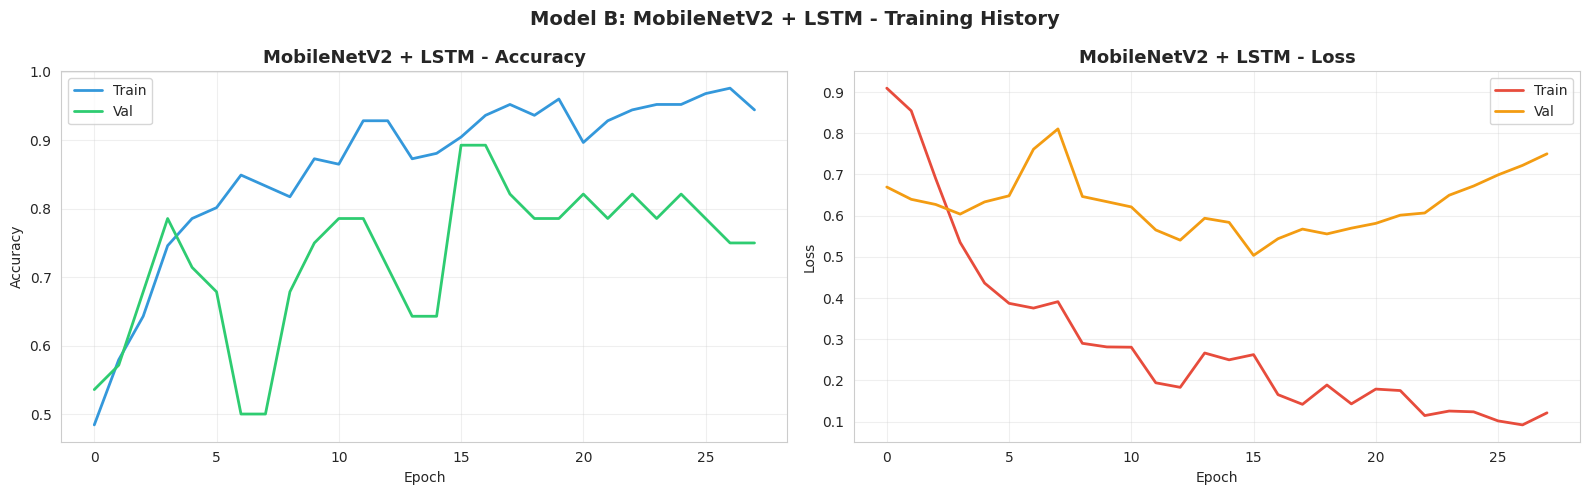

In [ ]:
# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(lstm_history.history['accuracy'],     label='Train', color='#3498db', lw=2)
axes[0].plot(lstm_history.history['val_accuracy'], label='Val',   color='#2ecc71', lw=2)
axes[0].set_title('MobileNetV2 + LSTM - Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(lstm_history.history['loss'],     label='Train', color='#e74c3c', lw=2)
axes[1].plot(lstm_history.history['val_loss'], label='Val',   color='#f39c12', lw=2)
axes[1].set_title('MobileNetV2 + LSTM - Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Model B: MobileNetV2 + LSTM - Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6e. Evaluate LSTM on Test Set

In [ ]:
lstm_best_model  = keras.models.load_model('lstm_best.keras')
lstm_test_loss, lstm_test_acc = lstm_best_model.evaluate(X_test_n, y_test_cat, verbose=1)
lstm_pred_proba  = lstm_best_model.predict(X_test_n, verbose=0)
lstm_pred        = np.argmax(lstm_pred_proba, axis=1)
lstm_true        = y_test

lstm_f1        = f1_score(lstm_true, lstm_pred)
lstm_precision = precision_score(lstm_true, lstm_pred)
lstm_recall    = recall_score(lstm_true, lstm_pred)
fpr_lstm, tpr_lstm, _ = roc_curve(lstm_true, lstm_pred_proba[:, 1])
lstm_auc       = auc(fpr_lstm, tpr_lstm)

print('=== MODEL B: MobileNetV2 + LSTM - Test Results ===')
print(f'Accuracy  : {lstm_test_acc:.4f}')
print(f'F1 Score  : {lstm_f1:.4f}')
print(f'Precision : {lstm_precision:.4f}')
print(f'Recall    : {lstm_recall:.4f}')
print(f'ROC AUC   : {lstm_auc:.4f}')
print()
print(classification_report(lstm_true, lstm_pred, target_names=CLASS_NAMES))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.6289
=== MODEL B: MobileNetV2 + LSTM - Test Results ===
Accuracy  : 0.7500
F1 Score  : 0.7879
Precision : 0.6842
Recall    : 0.9286
ROC AUC   : 0.7857

              precision    recall  f1-score   support

      Normal       0.89      0.57      0.70        14
 Shoplifting       0.68      0.93      0.79        14

    accuracy                           0.75        28
   macro avg       0.79      0.75      0.74        28
weighted avg       0.79      0.75      0.74        28



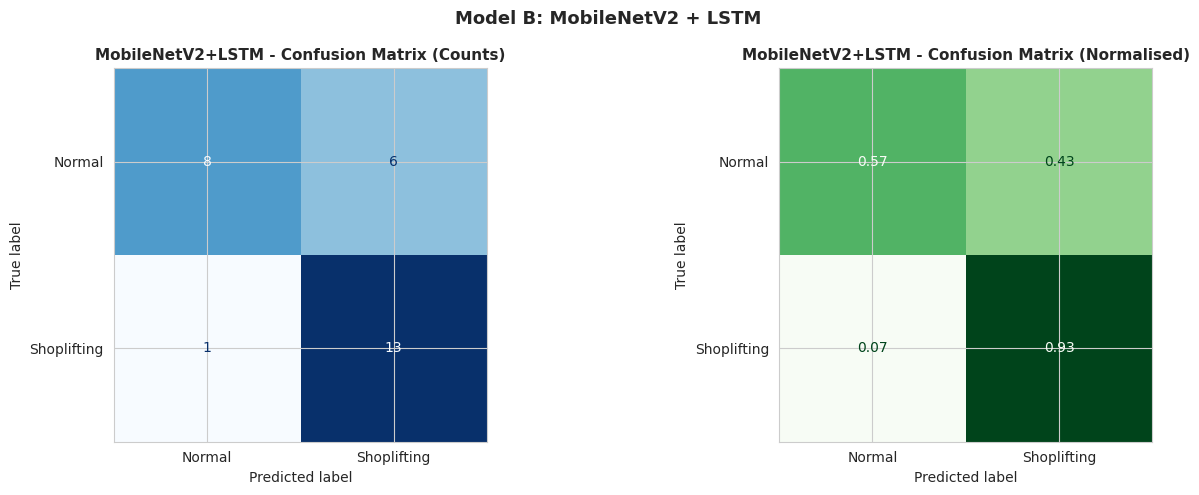

In [ ]:
# LSTM confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_lstm = confusion_matrix(lstm_true, lstm_pred)

ConfusionMatrixDisplay(cm_lstm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('MobileNetV2+LSTM - Confusion Matrix (Counts)', fontsize=11, fontweight='bold')

cm_lstm_norm = cm_lstm.astype('float') / cm_lstm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_lstm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('MobileNetV2+LSTM - Confusion Matrix (Normalised)', fontsize=11, fontweight='bold')

plt.suptitle('Model B: MobileNetV2 + LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

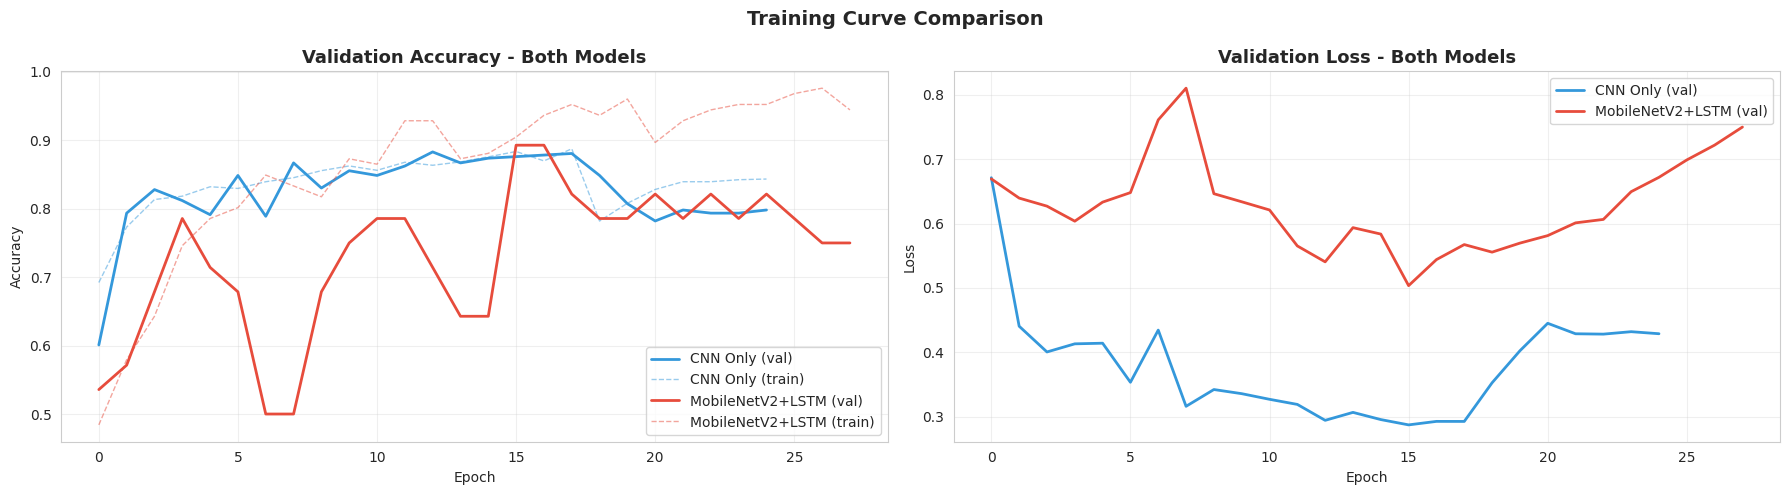

In [ ]:
# Training curve comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Accuracy curves
axes[0].plot(cnn_val,  color='#3498db', lw=2, label='CNN Only (val)')
axes[0].plot(cnn_acc,  color='#3498db', lw=1, ls='--', alpha=0.5, label='CNN Only (train)')
axes[0].plot(lstm_history.history['val_accuracy'], color='#e74c3c', lw=2, label='MobileNetV2+LSTM (val)')
axes[0].plot(lstm_history.history['accuracy'],     color='#e74c3c', lw=1, ls='--', alpha=0.5, label='MobileNetV2+LSTM (train)')
axes[0].set_title('Validation Accuracy - Both Models', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss curves
axes[1].plot(cnn_vloss, color='#3498db', lw=2, label='CNN Only (val)')
axes[1].plot(lstm_history.history['val_loss'], color='#e74c3c', lw=2, label='MobileNetV2+LSTM (val)')
axes[1].set_title('Validation Loss - Both Models', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Curve Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Model C Efficient NetB0**

In [ ]:
# EfficientNetB0 feature extractor
base_eff = EfficientNetB0(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_eff.trainable = False

eff_extractor = Model(
    inputs=base_eff.input,
    outputs=layers.GlobalAveragePooling2D()(base_eff.output),
    name='EfficientNetB0_Extractor'
)
print(f'EfficientNet output shape: {eff_extractor.output_shape}')
EFF_FEATURE_DIM = eff_extractor.output_shape[-1]
print(f'Feature dim: {EFF_FEATURE_DIM}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNet output shape: (None, 1280)
Feature dim: 1280


In [ ]:
print(f'Extracting EfficientNet features from {len(df)} videos...')
X_eff, y_eff = [], []

for i, row in df.iterrows():
    frames, _, _ = extract_frames(row['path'], FRAMES_PER_VID)
    if not frames:
        continue
    frames_arr = np.array(frames, dtype=np.float32)
    # EfficientNet uses its own preprocessing
    frames_pp  = efficientnet_preprocess(frames_arr.copy())
    features   = eff_extractor.predict(frames_pp, verbose=0)
    X_eff.append(features)
    y_eff.append(row['label'])
    if (i + 1) % 30 == 0:
        print(f'  [{i+1}/{len(df)}] processed')

X_eff = np.array(X_eff, dtype=np.float32)
y_eff = np.array(y_eff, dtype=np.int32)
print(f'EfficientNet feature shape: {X_eff.shape}')
gc.collect()

Extracting EfficientNet features from 182 videos...
  [30/182] processed
  [60/182] processed
  [90/182] processed
  [120/182] processed
  [150/182] processed
  [180/182] processed
EfficientNet feature shape: (182, 16, 1280)


21691

In [ ]:
# Same 70/15/15 split
X_eff_tmp,  X_eff_test,  y_eff_tmp,  y_eff_test  = train_test_split(
    X_eff, y_eff, test_size=0.15, stratify=y_eff, random_state=SEED)
X_eff_train, X_eff_val, y_eff_train, y_eff_val = train_test_split(
    X_eff_tmp, y_eff_tmp, test_size=0.176, stratify=y_eff_tmp, random_state=SEED)
del X_eff_tmp, y_eff_tmp
gc.collect()

# Normalize
eff_mean = X_eff_train.mean()
eff_std  = X_eff_train.std() + 1e-8
X_eff_train_n = (X_eff_train - eff_mean) / eff_std
X_eff_val_n   = (X_eff_val   - eff_mean) / eff_std
X_eff_test_n  = (X_eff_test  - eff_mean) / eff_std

y_eff_train_cat = to_categorical(y_eff_train, 2)
y_eff_val_cat   = to_categorical(y_eff_val,   2)
y_eff_test_cat  = to_categorical(y_eff_test,  2)

# Save normalization params
np.save('eff_mean.npy', np.array([eff_mean]))
np.save('eff_std.npy',  np.array([eff_std]))

cw_eff     = compute_class_weight('balanced', classes=np.unique(y_eff_train), y=y_eff_train)
cw_eff_dict = dict(enumerate(cw_eff))
print(f'Train: {len(X_eff_train)} | Val: {len(X_eff_val)} | Test: {len(X_eff_test)}')

Train: 126 | Val: 28 | Test: 28


Building the model

In [ ]:
def build_eff_lstm_model(seq_len, feat_dim):
    """
    Bidirectional LSTM classifier using EfficientNetB0 features.
    EfficientNetB0 provides richer 1280-dim features vs MobileNetV2.
    """
    inputs = keras.Input(shape=(seq_len, feat_dim))

    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True, dropout=0.3)
    )(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=False, dropout=0.3)
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation='softmax')(x)

    return Model(inputs, outputs, name='EfficientNetB0_LSTM')


eff_model = build_eff_lstm_model(FRAMES_PER_VID, EFF_FEATURE_DIM)
eff_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('EfficientNet + LSTM summary:')
eff_model.summary()
print(f'Total params: {eff_model.count_params():,}')

EfficientNet + LSTM summary:


Model: "EfficientNetB0_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 16, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 16, 512)        │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,906,178 (14.90 MB)

 Trainable params: 3,904,642 (14.90 MB)

 Non-trainable params: 1,536 (6.00 KB)

Total params: 3,906,178


In [ ]:
print('--- EfficientNetB0 + LSTM Training ---')

eff_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                   restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4,
                       patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('eff_lstm_best.keras', monitor='val_accuracy',
                     save_best_only=True, verbose=1)
]

eff_history = eff_model.fit(
    X_eff_train_n, y_eff_train_cat,
    validation_data=(X_eff_val_n, y_eff_val_cat),
    epochs=80,
    batch_size=BATCH_SIZE,
    class_weight=cw_eff_dict,
    callbacks=eff_callbacks,
    verbose=1
)
eff_best_val = max(eff_history.history['val_accuracy'])
print(f'Best val accuracy: {eff_best_val:.4f}')

--- EfficientNetB0 + LSTM Training ---
Epoch 1/80
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7934 - loss: 0.4426
Epoch 1: val_accuracy improved from None to 0.82143, saving model to eff_lstm_best.keras

Epoch 1: finished saving model to eff_lstm_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7857 - loss: 0.4358 - val_accuracy: 0.8214 - val_loss: 0.5206 - learning_rate: 4.0000e-04
Epoch 2/80
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8798 - loss: 0.3910
Epoch 2: val_accuracy did not improve from 0.82143
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8651 - loss: 0.3755 - val_accuracy: 0.8214 - val_loss: 0.5185 - learning_rate: 4.0000e-04
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8915 - loss: 0.3005
Epoch 3: val_accuracy did not improve from 0.82143
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8651 - loss: 0.3100 - val_accuracy: 0.8214 - val_loss: 0.5233 - learning_rate: 4.0000e-04
Epoch 4/80
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1

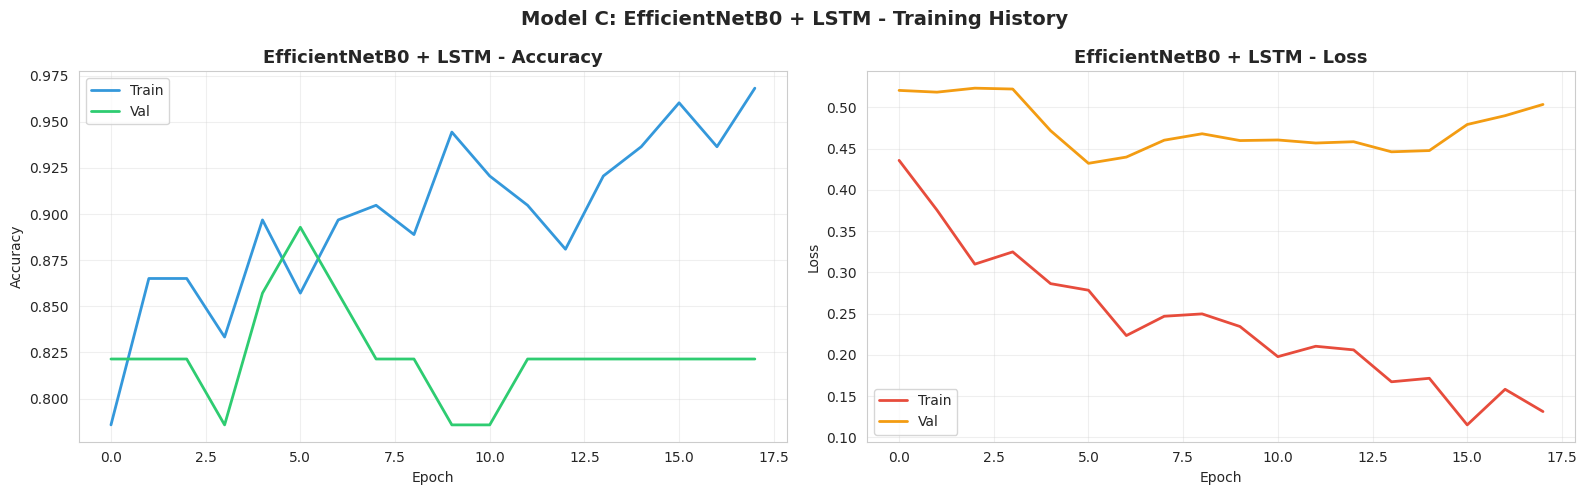

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(eff_history.history['accuracy'],     label='Train', color='#3498db', lw=2)
axes[0].plot(eff_history.history['val_accuracy'], label='Val',   color='#2ecc71', lw=2)
axes[0].set_title('EfficientNetB0 + LSTM - Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eff_history.history['loss'],     label='Train', color='#e74c3c', lw=2)
axes[1].plot(eff_history.history['val_loss'], label='Val',   color='#f39c12', lw=2)
axes[1].set_title('EfficientNetB0 + LSTM - Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Model C: EfficientNetB0 + LSTM - Training History',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
eff_best_model   = keras.models.load_model('eff_lstm_best.keras')
eff_test_loss, eff_test_acc = eff_best_model.evaluate(
    X_eff_test_n, y_eff_test_cat, verbose=1)
eff_pred_proba   = eff_best_model.predict(X_eff_test_n, verbose=0)
eff_pred         = np.argmax(eff_pred_proba, axis=1)
eff_true         = y_eff_test

eff_f1        = f1_score(eff_true, eff_pred)
eff_precision = precision_score(eff_true, eff_pred)
eff_recall    = recall_score(eff_true, eff_pred)
fpr_eff, tpr_eff, _ = roc_curve(eff_true, eff_pred_proba[:, 1])
eff_auc       = auc(fpr_eff, tpr_eff)

print('=== MODEL C: EfficientNetB0 + LSTM - Test Results ===')
print(f'Accuracy  : {eff_test_acc:.4f}')
print(f'F1 Score  : {eff_f1:.4f}')
print(f'Precision : {eff_precision:.4f}')
print(f'Recall    : {eff_recall:.4f}')
print(f'ROC AUC   : {eff_auc:.4f}')
print()
print(classification_report(eff_true, eff_pred, target_names=CLASS_NAMES))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7857 - loss: 0.5452
=== MODEL C: EfficientNetB0 + LSTM - Test Results ===
Accuracy  : 0.7857
F1 Score  : 0.7500
Precision : 0.9000
Recall    : 0.6429
ROC AUC   : 0.7959

              precision    recall  f1-score   support

      Normal       0.72      0.93      0.81        14
 Shoplifting       0.90      0.64      0.75        14

    accuracy                           0.79        28
   macro avg       0.81      0.79      0.78        28
weighted avg       0.81      0.79      0.78        28



In [ ]:
# Three model comparison table
results = pd.DataFrame({
    'Metric':              ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC'],
    'CNN Only':            [cnn_test_acc, cnn_f1, cnn_precision, cnn_recall, cnn_auc],
    'MobileNetV2 + LSTM':  [lstm_test_acc, lstm_f1, lstm_precision, lstm_recall, lstm_auc],
    'EfficientNetB0 + LSTM':[eff_test_acc, eff_f1, eff_precision, eff_recall, eff_auc]
})

print('=== FINAL THREE MODEL COMPARISON ===')
print(results.round(4).to_string(index=False))

best_acc   = max(cnn_test_acc, lstm_test_acc, eff_test_acc)
model_names = ['CNN Only', 'MobileNetV2+LSTM', 'EfficientNetB0+LSTM']
model_accs  = [cnn_test_acc, lstm_test_acc, eff_test_acc]
winner      = model_names[model_accs.index(max(model_accs))]
print(f'\nOverall winner by accuracy: {winner}')

=== FINAL THREE MODEL COMPARISON ===
   Metric  CNN Only  MobileNetV2 + LSTM  EfficientNetB0 + LSTM
 Accuracy    0.8519              0.7500                 0.7857
 F1 Score    0.8403              0.7879                 0.7500
Precision    0.9243              0.6842                 0.9000
   Recall    0.7703              0.9286                 0.6429
  ROC AUC    0.9309              0.7857                 0.7959

Overall winner by accuracy: CNN Only


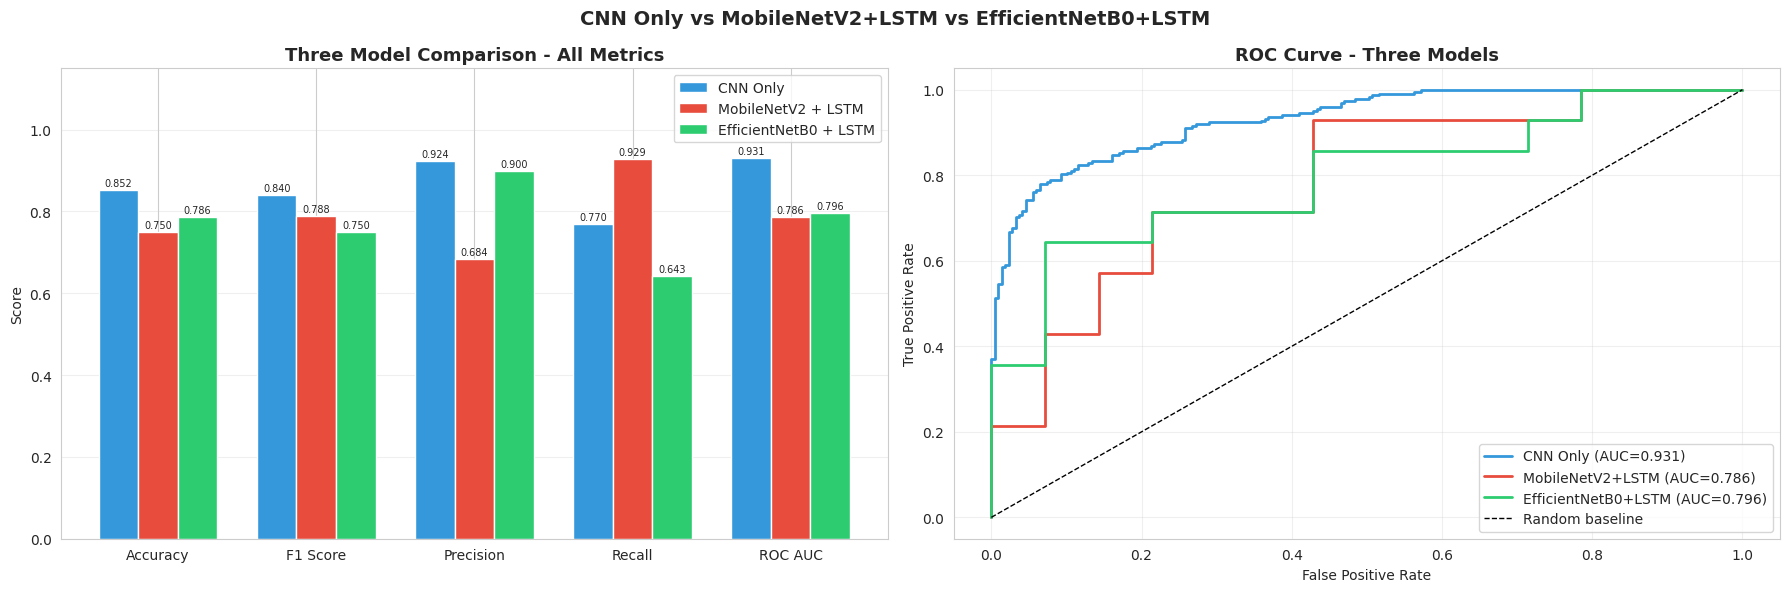

In [ ]:
metrics    = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']
cnn_vals   = [cnn_test_acc,  cnn_f1,  cnn_precision,  cnn_recall,  cnn_auc]
lstm_vals  = [lstm_test_acc, lstm_f1, lstm_precision,  lstm_recall, lstm_auc]
eff_vals   = [eff_test_acc,  eff_f1,  eff_precision,   eff_recall,  eff_auc]

x     = np.arange(len(metrics))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
b1 = axes[0].bar(x - width, cnn_vals,  width, label='CNN Only',             color='#3498db', edgecolor='white')
b2 = axes[0].bar(x,         lstm_vals, width, label='MobileNetV2 + LSTM',   color='#e74c3c', edgecolor='white')
b3 = axes[0].bar(x + width, eff_vals,  width, label='EfficientNetB0 + LSTM',color='#2ecc71', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score')
axes[0].set_title('Three Model Comparison - All Metrics', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.01,
                      f'{bar.get_height():.3f}',
                      ha='center', fontsize=7)

# ROC curves
axes[1].plot(fpr_cnn,  tpr_cnn,  color='#3498db', lw=2, label=f'CNN Only (AUC={cnn_auc:.3f})')
axes[1].plot(fpr_lstm, tpr_lstm, color='#e74c3c', lw=2, label=f'MobileNetV2+LSTM (AUC={lstm_auc:.3f})')
axes[1].plot(fpr_eff,  tpr_eff,  color='#2ecc71', lw=2, label=f'EfficientNetB0+LSTM (AUC={eff_auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
axes[1].set_title('ROC Curve - Three Models', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('CNN Only vs MobileNetV2+LSTM vs EfficientNetB0+LSTM',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Save and Download Models

In [ ]:
from google.colab import files
import shutil

# Save all models
cnn_best_model.save('shoplifting_cnn.keras')
lstm_best_model.save('shoplifting_lstm.keras')
eff_best_model.save('eff_lstm_best.keras')
feature_extractor.save('feature_extractor.keras')

# Save EfficientNet normalization params
np.save('eff_mean.npy', np.array([eff_mean]))
np.save('eff_std.npy',  np.array([eff_std]))

# Save MobileNet normalization params (already saved earlier but saving again to be safe)
np.save('feat_mean.npy', np.array([feat_mean]))
np.save('feat_std.npy',  np.array([feat_std]))

# Save config with all 3 model results
config = {
    'class_names':     CLASS_NAMES,
    'frames_per_vid':  FRAMES_PER_VID,
    'img_size':        list(IMG_SIZE),
    'feature_dim':     FEATURE_DIM,
    'cnn_test_acc':    float(cnn_test_acc),
    'lstm_test_acc':   float(lstm_test_acc),
    'eff_test_acc':    float(eff_test_acc),
    'cnn_auc':         float(cnn_auc),
    'lstm_auc':        float(lstm_auc),
    'eff_auc':         float(eff_auc),
    'winner':          winner
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Backup all to Drive
save_dir = os.path.join(DATASET_PATH, 'saved_models')
os.makedirs(save_dir, exist_ok=True)
all_files = [
    'shoplifting_cnn.keras',
    'shoplifting_lstm.keras',
    'eff_lstm_best.keras',
    'feature_extractor.keras',
    'model_config.json',
    'feat_mean.npy',
    'feat_std.npy',
    'eff_mean.npy',
    'eff_std.npy'
]
for fname in all_files:
    shutil.copy(fname, os.path.join(save_dir, fname))
    print(f'Backed up to Drive: {fname}')

# Download all to PC
print('\nDownloading to PC...')
for fname in all_files:
    files.download(fname)
    print(f'Downloaded: {fname}')

Backed up to Drive: shoplifting_cnn.keras
Backed up to Drive: shoplifting_lstm.keras
Backed up to Drive: eff_lstm_best.keras
Backed up to Drive: feature_extractor.keras
Backed up to Drive: model_config.json
Backed up to Drive: feat_mean.npy
Backed up to Drive: feat_std.npy
Backed up to Drive: eff_mean.npy
Backed up to Drive: eff_std.npy



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shoplifting_cnn.keras


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: eff_mean.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: eff_std.npy


In [48]:
# Resave all models in H5 format (version-compatible)
cnn_best_model.save('shoplifting_cnn.h5')
lstm_best_model.save('shoplifting_lstm.h5')
eff_best_model.save('eff_lstm_best.h5')
feature_extractor.save('feature_extractor.h5')

from google.colab import files
for f in ['shoplifting_cnn.h5','shoplifting_lstm.h5','eff_lstm_best.h5','feature_extractor.h5']:
    files.download(f)
    print(f'Downloaded: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shoplifting_cnn.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: eff_lstm_best.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: feature_extractor.h5
